In [18]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [19]:
dotenv_path = r"C:\Users\htpar\Desktop\Github\End to End Retail Data Warehouse\Forcasting\notebooks\.env"
load_dotenv(dotenv_path=dotenv_path, override=True)

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

In [20]:
engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [21]:
query = """
SELECT
    customer_id,
    total_orders,
    total_revenue,
    avg_order_revenue,
    recency_days,
    churn_label
FROM ml.train_feature_customer_churn
"""

df = pd.read_sql(query, engine)
df.head()

,customer_id,total_orders,total_revenue,avg_order_revenue,recency_days,churn_label
0,12346,1,77183.60,77183.600000,325,1
1,12347,7,4310.00,23.681319,2,0
2,12348,4,1797.24,57.975484,75,1
3,12349,1,1757.55,24.076027,18,0
4,12350,1,334.40,19.670588,310,1


In [22]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(4339, 6)
customer_id           object
total_orders           int64
total_revenue        float64
avg_order_revenue    float64
recency_days           int64
churn_label            int64
dtype: object
customer_id          0
total_orders         0
total_revenue        0
avg_order_revenue    0
recency_days         0
churn_label          0
dtype: int64


In [23]:
df = df.copy()

df["customer_id"] = pd.to_numeric(df["customer_id"], errors="coerce")

df = df.dropna(subset=[
    "customer_id",
    "total_orders",
    "total_revenue",
    "avg_order_revenue",
    "recency_days",
    "churn_label"
]).copy()

df.head()

,customer_id,total_orders,total_revenue,avg_order_revenue,recency_days,churn_label
0,12346,1,77183.60,77183.600000,325,1
1,12347,7,4310.00,23.681319,2,0
2,12348,4,1797.24,57.975484,75,1
3,12349,1,1757.55,24.076027,18,0
4,12350,1,334.40,19.670588,310,1


In [24]:
df["churn_label"].value_counts(dropna=False)

churn_label
0    2411
1    1928
Name: count, dtype: int64

In [25]:
feature_cols = [
    "total_orders",
    "total_revenue",
    "avg_order_revenue",
    "recency_days"
]

X = df[feature_cols]
y = df["churn_label"]

meta = df[["customer_id", "churn_label"]].copy()

In [26]:
X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X,
    y,
    meta,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(3471, 4) (868, 4)


In [27]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [28]:
proba = model.predict_proba(X_test)[:, 1]
pred_label = (proba >= 0.5).astype(int)

In [29]:
auc = roc_auc_score(y_test, proba)
print("ROC AUC:", round(auc, 4))

print("\nClassification Report")
print(classification_report(y_test, pred_label))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred_label))

ROC AUC: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       482
           1       1.00      1.00      1.00       386

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868


Confusion Matrix
[[482   0]
 [  0 386]]


In [30]:
result = meta_test.copy()
result["actual_churn_label"] = y_test.values
result["predicted_churn_probability"] = proba
result["predicted_churn_label"] = pred_label
result["model_name"] = "logistic_regression"

result = result[
    [
        "customer_id",
        "actual_churn_label",
        "predicted_churn_probability",
        "predicted_churn_label",
        "model_name"
    ]
]

result.head()

,customer_id,actual_churn_label,predicted_churn_probability,predicted_churn_label,model_name
724,13308,0,6.142364e-54,0,logistic_regression
4016,17849,1,1.000000e+00,1,logistic_regression
1291,14098,0,1.357354e-34,0,logistic_regression
1671,14622,1,1.000000e+00,1,logistic_regression
1740,14713,0,4.081876e-72,0,logistic_regression


In [31]:
result.sort_values("predicted_churn_probability", ascending=False).head(20)

,customer_id,actual_churn_label,predicted_churn_probability,predicted_churn_label,model_name
4016,17849,1,1.0,1,logistic_regression
1671,14622,1,1.0,1,logistic_regression
2902,16306,1,1.0,1,logistic_regression
2770,16122,1,1.0,1,logistic_regression
328,12750,1,1.0,1,logistic_regression
3029,16471,1,1.0,1,logistic_regression
3726,17446,1,1.0,1,logistic_regression
442,12917,1,1.0,1,logistic_regression
3531,17171,1,1.0,1,logistic_regression
923,13583,1,1.0,1,logistic_regression


In [34]:
save_path = r"C:\Users\htpar\Desktop\Github\End to End Retail Data Warehouse\Forcasting\result\prediction_customer_churn.csv"

result.to_csv(save_path, index=False)
print("saved:", save_path)

saved: C:\Users\htpar\Desktop\Github\End to End Retail Data Warehouse\Forcasting\result\prediction_customer_churn.csv


In [35]:
result.to_sql(
    "prediction_customer_churn",
    engine,
    schema="ml",
    if_exists="append",
    index=False
)

print("Inserted into ml.prediction_customer_churn")

Inserted into ml.prediction_customer_churn


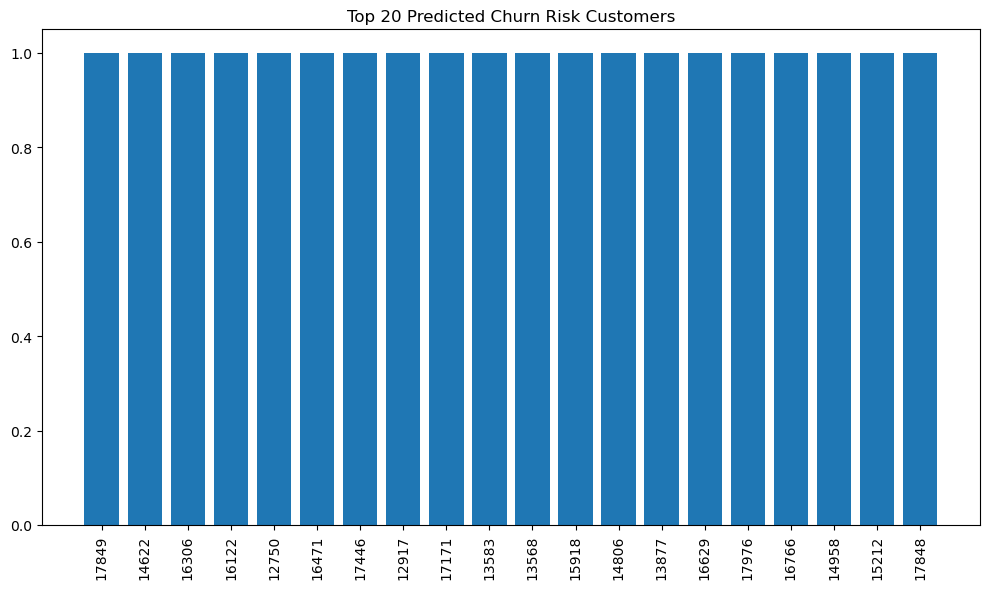

saved: C:\Users\htpar\Desktop\Github\End to End Retail Data Warehouse\Forcasting\result\churn_top20.png


In [37]:
save_fig_path = r"C:\Users\htpar\Desktop\Github\End to End Retail Data Warehouse\Forcasting\result\churn_top20.png"

plt.figure(figsize=(10, 6))
plt.bar(range(len(top_churn)), top_churn["predicted_churn_probability"])
plt.xticks(range(len(top_churn)), top_churn["customer_id"].astype(str), rotation=90)
plt.title("Top 20 Predicted Churn Risk Customers")
plt.tight_layout()
plt.savefig(save_fig_path)
plt.show()

print("saved:", save_fig_path)